# Analyse a sweep with the plate modelled as a mesh

Opacity of the plate was set to 0.8, allowing partial transmission of particles. Does this increase back plate impingement rate?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

In [4]:
df = pd.read_csv("summary.csv")

## First look

In [5]:
df.head()

,c10_equiv_abs,c10_imping_rate,c10_mc_hits,c11_equiv_abs,c11_imping_rate,c11_mc_hits,c12_equiv_abs,c12_imping_rate,c12_mc_hits,c13_equiv_abs,...,deflector_imping_rate,deflector_mc_hits,plate_back_equiv_abs,plate_back_imping_rate,plate_back_mc_hits,plate_front_equiv_abs,plate_front_imping_rate,plate_front_mc_hits,total_des,error
0,0.0,4.465597e+18,3697.0,0.0,4.716840e+18,3905.0,0.0,4.609337e+18,3816.0,0.0,...,7.616380e+18,302739.0,9168.0,5.284078e+18,11510.0,43695.0,2.507114e+19,54611.0,100000.0,NaN
1,0.0,3.987270e+18,3301.0,0.0,4.127386e+18,3417.0,0.0,3.937746e+18,3260.0,0.0,...,7.315135e+18,290765.0,8423.0,4.856669e+18,10579.0,42487.0,2.441602e+19,53184.0,100000.0,NaN
2,0.0,3.405063e+18,2819.0,0.0,3.541556e+18,2932.0,0.0,3.504111e+18,2901.0,0.0,...,7.081063e+18,281461.0,7219.0,4.127182e+18,8990.0,42297.0,2.433155e+19,53000.0,100000.0,NaN
3,0.0,3.081347e+18,2551.0,0.0,3.153821e+18,2611.0,0.0,3.043902e+18,2520.0,0.0,...,6.896603e+18,274129.0,6005.0,3.449112e+18,7513.0,41745.0,2.400285e+19,52284.0,100000.0,NaN
4,0.0,2.737096e+18,2266.0,0.0,2.799907e+18,2318.0,0.0,2.747967e+18,2275.0,0.0,...,6.847192e+18,272165.0,5167.0,2.946413e+18,6418.0,41324.0,2.374989e+19,51733.0,100000.0,NaN


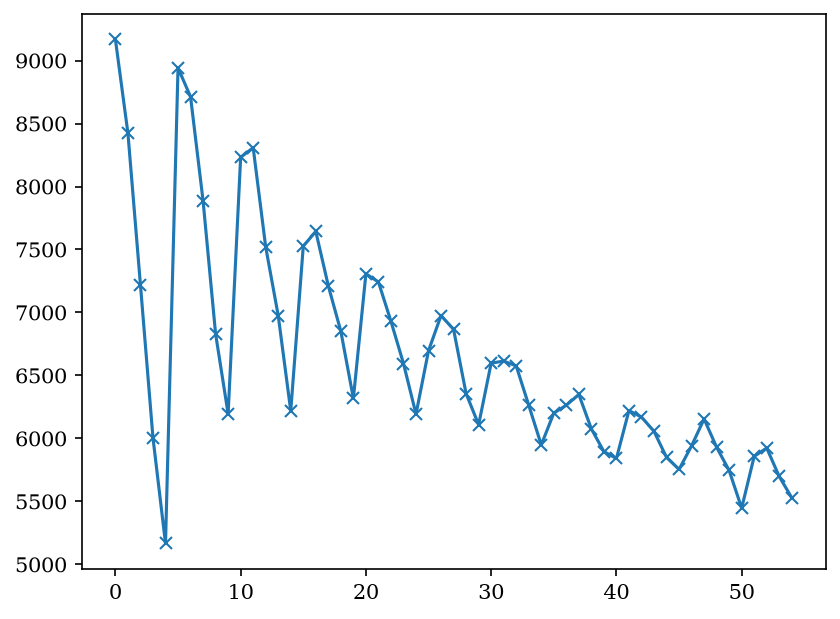

In [6]:
plt.plot(df['plate_back_equiv_abs'],"x-")

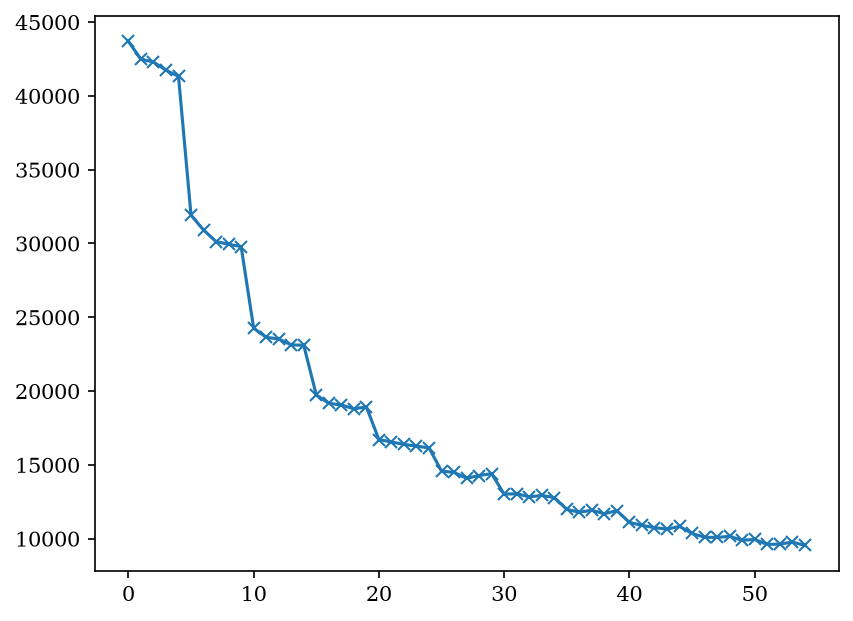

In [7]:
plt.plot(df['plate_front_equiv_abs'],"x-")

Why is front plate impingement higher than the solid plate case?? - Answer was tracking impingement rate which counts all hits. Should have been tracking equiv abs.

In [8]:
dist = []

plate_dist = 0
cone_dist = 0


#construct plate and distance pattern
for i in range(11):
    cone_dist = plate_dist - 0.25
    for i in range(5):
        dist.append([plate_dist, cone_dist])
        cone_dist += 0.25 

    cone_dist = -0.25
    plate_dist += 0.5

print(dist)


[[0, -0.25], [0, 0.0], [0, 0.25], [0, 0.5], [0, 0.75], [0.5, 0.25], [0.5, 0.5], [0.5, 0.75], [0.5, 1.0], [0.5, 1.25], [1.0, 0.75], [1.0, 1.0], [1.0, 1.25], [1.0, 1.5], [1.0, 1.75], [1.5, 1.25], [1.5, 1.5], [1.5, 1.75], [1.5, 2.0], [1.5, 2.25], [2.0, 1.75], [2.0, 2.0], [2.0, 2.25], [2.0, 2.5], [2.0, 2.75], [2.5, 2.25], [2.5, 2.5], [2.5, 2.75], [2.5, 3.0], [2.5, 3.25], [3.0, 2.75], [3.0, 3.0], [3.0, 3.25], [3.0, 3.5], [3.0, 3.75], [3.5, 3.25], [3.5, 3.5], [3.5, 3.75], [3.5, 4.0], [3.5, 4.25], [4.0, 3.75], [4.0, 4.0], [4.0, 4.25], [4.0, 4.5], [4.0, 4.75], [4.5, 4.25], [4.5, 4.5], [4.5, 4.75], [4.5, 5.0], [4.5, 5.25], [5.0, 4.75], [5.0, 5.0], [5.0, 5.25], [5.0, 5.5], [5.0, 5.75]]


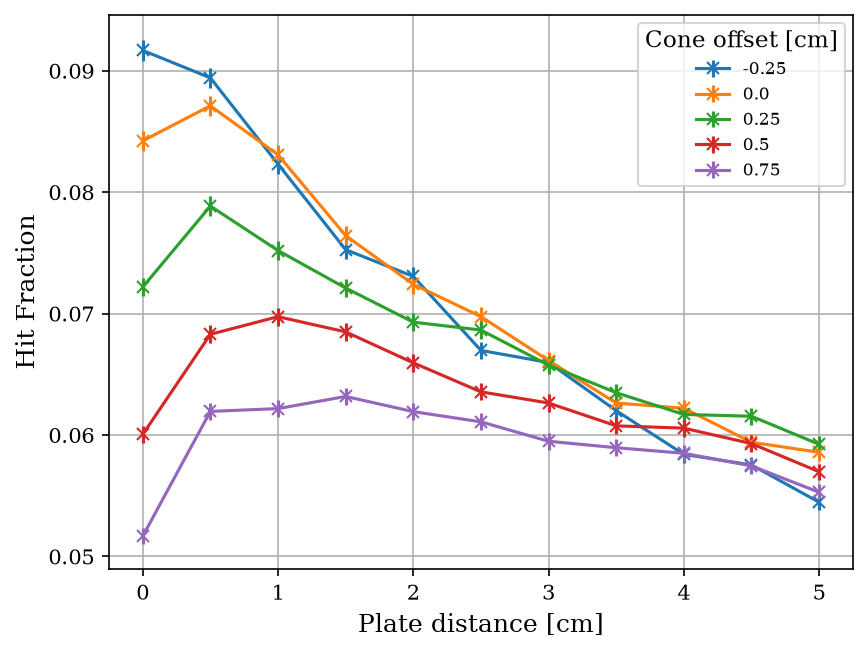

In [9]:
dist = np.array(dist)
intensity = np.array(df['plate_back_equiv_abs'] / df['total_des'])

plate = dist[:, 0]
cone = dist[:, 1]
offset = np.round(cone - plate, 2)


fig, ax = plt.subplots()

for o in np.unique(offset):
    mask = offset == o
    order = np.argsort(plate[mask])
    ax.errorbar(plate[mask][order], intensity[mask][order], yerr=intensity[mask][order]/np.sqrt(df["plate_back_mc_hits"][mask]), fmt="x-", label=f'{o}')




ax.set_xlabel('Plate distance [cm]')
ax.set_ylabel('Hit Fraction')
ax.legend(title='Cone offset [cm]',loc="best", fontsize=8)
ax.grid()
plt.savefig("cone_meshplate_sweep.png", dpi=300, bbox_inches='tight')

## Deflector

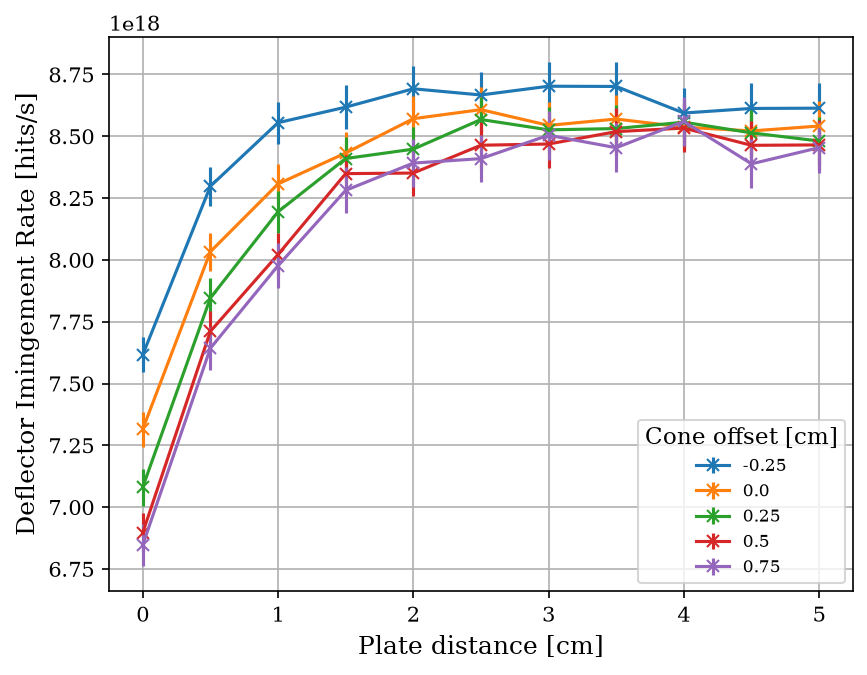

In [10]:
fig, ax = plt.subplots()

intensity = np.array(df['deflector_imping_rate'])

for o in np.unique(offset):
    mask = offset == o
    order = np.argsort(plate[mask])
    ax.errorbar(plate[mask][order], intensity[mask][order], yerr=intensity[mask][order]/np.sqrt(df["plate_back_mc_hits"][mask]), fmt="x-", label=f'{o}')

ax.set_xlabel('Plate distance [cm]')
ax.set_ylabel('Deflector Imingement Rate [hits/s]')
ax.legend(title='Cone offset [cm]',loc="best", fontsize=8)
ax.grid()
